In [27]:
import requests
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import platform

In [28]:
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus']=False

In [29]:
#데이터 수집 (openapi)
url = 'https://api.thingspeak.com/channels/12397/feeds.json?results=500'
res=requests.get(url)
data=res.json()
data

{'channel': {'id': 12397,
  'name': 'WeatherStation',
  'description': 'MathWorks Weather Station, West Garage, Natick, MA 01760, USA',
  'latitude': '42.299676',
  'longitude': '-71.350525',
  'field1': 'Wind Direction (North = 0 degrees)',
  'field2': 'Wind Speed (mph)',
  'field3': '% Humidity',
  'field4': 'Temperature (F)',
  'field5': 'Rain (Inches/minute)',
  'field6': 'Pressure ("Hg)',
  'field7': 'Power Level (V)',
  'field8': 'Light Intensity',
  'created_at': '2014-05-20T21:50:32Z',
  'updated_at': '2025-10-02T21:56:57Z',
  'elevation': '60',
  'last_entry_id': 5606140},
 'feeds': [{'created_at': '2026-05-26T22:57:38Z',
   'entry_id': 5605641,
   'field1': '139',
   'field2': '4.3',
   'field3': '0',
   'field4': '0.1',
   'field5': '0',
   'field6': '29.72',
   'field7': '0',
   'field8': '0'},
  {'created_at': '2026-05-26T22:58:38Z',
   'entry_id': 5605642,
   'field1': '131',
   'field2': '5.7',
   'field3': '0',
   'field4': '0.1',
   'field5': '0',
   'field6': '29.72',

- field1 : 풍향 -> 도 단위 (0 ~ 360)
- field2 : 풍속(m/s)
- field3 : 상대 습도(%)
- field4 : 기온 -> 화씨 단위
- field5 : 강우량(mm)
- field6 : 기압(nPa)
- field7 : 조도/일사량 -> 빛의 세기
- field 8 : 센서 베터리의 전압 -> 장비의 전원 상태(V)

In [30]:
df=pd.DataFrame(data['feeds'])
df.head(10)

,created_at,entry_id,field1,field2,field3,field4,field5,field6,field7,field8
0,2026-05-26T22:57:38Z,5605641,139,4.3,0,0.1,0,29.72,0,0
1,2026-05-26T22:58:38Z,5605642,131,5.7,0,0.1,0,29.72,0,0
2,2026-05-26T22:59:38Z,5605643,0,8.9,0,0.1,0,29.72,0,0
3,2026-05-26T23:00:38Z,5605644,124,7.9,0,0.1,0,29.72,0,0
4,2026-05-26T23:01:38Z,5605645,108,7,0,0.1,0,29.72,0,0
5,2026-05-26T23:03:38Z,5605646,113,7.7,0,0.1,0,29.72,0,0
6,2026-05-26T23:05:38Z,5605647,113,5.6,0,0.1,0,29.72,0,0
7,2026-05-26T23:06:38Z,5605648,125,4.1,0,0.1,0,29.72,0,0
8,2026-05-26T23:07:38Z,5605649,113,3.8,0,0.1,0,29.72,0,0
9,2026-05-26T23:08:38Z,5605650,113,3.8,0,0.1,0,29.72,0,0


In [31]:
df=df[['created_at', 'field2']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   created_at  500 non-null    object
 1   field2      500 non-null    object
dtypes: object(2)
memory usage: 7.9+ KB


In [32]:
df.columns=['time', 'value']
df.describe()

,time,value
count,500,500
unique,500,80
top,2026-05-26T22:57:38Z,4
freq,1,21


In [33]:
df['value']=pd.to_numeric(df['value'])
df.describe()

,value
count,500.000000
mean,4.587600
std,1.604879
min,1.300000
25%,3.400000
50%,4.300000
75%,5.500000
max,11.900000


In [34]:
#정규화 -> 스케일링
scaler=MinMaxScaler()
df['scaled_value']=scaler.fit_transform(df[['value']])
df.head()

,time,value,scaled_value
0,2026-05-26T22:57:38Z,4.3,0.283019
1,2026-05-26T22:58:38Z,5.7,0.415094
2,2026-05-26T22:59:38Z,8.9,0.716981
3,2026-05-26T23:00:38Z,7.9,0.622642
4,2026-05-26T23:01:38Z,7.0,0.537736


In [35]:
features=df[['scaled_value']].values
features

array([[0.28301887],
       [0.41509434],
       [0.71698113],
       [0.62264151],
       [0.53773585],
       [0.60377358],
       [0.40566038],
       [0.26415094],
       [0.23584906],
       [0.23584906],
       [0.31132075],
       [0.32075472],
       [0.14150943],
       [0.22641509],
       [0.21698113],
       [0.47169811],
       [0.36792453],
       [0.44339623],
       [0.36792453],
       [0.19811321],
       [0.21698113],
       [0.4245283 ],
       [0.43396226],
       [0.25471698],
       [0.38679245],
       [0.41509434],
       [0.64150943],
       [0.49056604],
       [0.45283019],
       [0.64150943],
       [0.59433962],
       [0.74528302],
       [0.47169811],
       [0.32075472],
       [0.52830189],
       [0.60377358],
       [0.45283019],
       [0.70754717],
       [0.50943396],
       [0.5       ],
       [0.55660377],
       [0.81132075],
       [0.79245283],
       [0.6509434 ],
       [0.64150943],
       [0.4245283 ],
       [0.38679245],
       [0.349

In [43]:
class windowDS(Dataset):
    def __init__(self, _x , _window):
        self.data = _x
        self.window = _window
        self.n = len(_x) - _window
    def __len__(self):
        return self.n
    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window]
        y = self.data[idx + self.window]
        x_tensor = torch.from_numpy(x).float()
        y_tensor = torch.tensor(y).float()
        return x_tensor, y_tensor

In [44]:
sensor_ds=windowDS(features, 10)

train_dl=DataLoader(sensor_ds, batch_size=32, shuffle=False)

In [45]:
class SensorLSTM(nn.Module):
    def __init__(
            self,
            input_size,
            hidden_size
    ):
        super(SensorLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.model =nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        pred=self.model(h_n[-1])
        return pred

In [46]:
model=SensorLSTM(1, 16)
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

In [47]:
model.train()
for epoch in range(30):
    total_loss = 0.0
    total_n = 0
    for x, y in train_dl:
        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        total_n = y.size(0)
    train_loss = total_loss / max(total_n, 1)

    if (epoch+1) % 5 == 0:
        print(f"Epoch : {epoch+1}, MSE : {train_loss}")

Epoch : 5, MSE : 0.8507489844225347
Epoch : 10, MSE : 0.6857700360007584
Epoch : 15, MSE : 0.6101727506145835
Epoch : 20, MSE : 0.6066665990278125
Epoch : 25, MSE : 0.5987925627268851
Epoch : 30, MSE : 0.5940564515069127


In [48]:
# 예측 값 -> 기존의 데이터를 이용해서 예측 ( 원본의 데이터 모두를 예측 ) 
model.eval()

full_loader = DataLoader( sensor_ds, batch_size=len(sensor_ds), shuffle=False )
# for x, y in full_loader:
    # pass
# next(iter(DataLoader)) : 생성된 데이터들중 첫번째 데이터셋을 로드한다. 
x, y = next(iter(full_loader))

with torch.no_grad():
    pred = model(x)
    errors = torch.abs(y - pred).numpy()

# 오차의 분포에서 상위 5% 지점을 이상치 임계값 설정 
threshold = np.percentile(errors, 90)
anomalies = errors > threshold

In [49]:
print('임계 지점의 값 : ', round(threshold, 4))

임계 지점의 값 :  0.1754


In [52]:
print(df.columns)

Index(['time', 'value', 'scaled_value'], dtype='object')


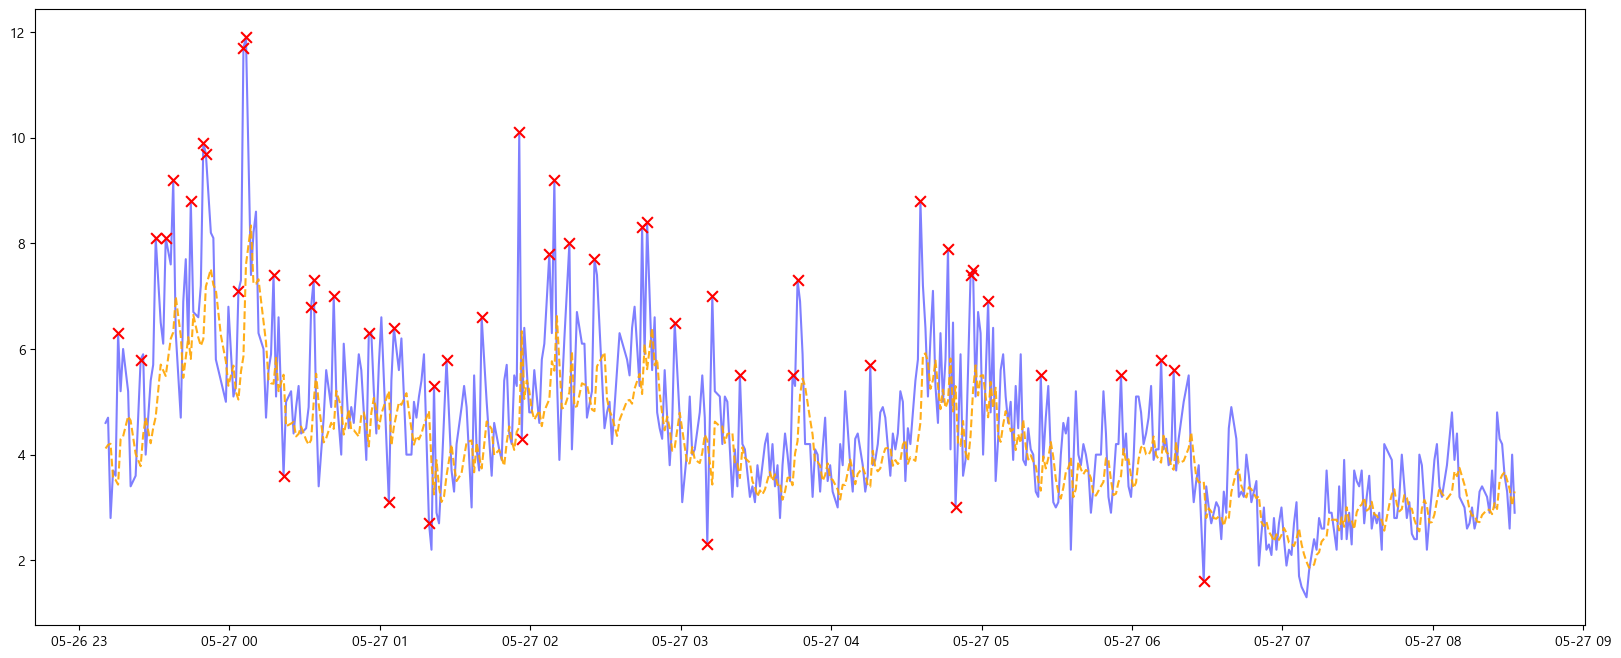

In [53]:
true_y = scaler.inverse_transform(y)
pred_y = scaler.inverse_transform(pred)
df['time'] = pd.to_datetime(df['time'])
plot_x = df['time'].iloc[10:].values

plt.figure(figsize=(20, 8))

plt.plot(plot_x, true_y, label = '실제 센서 데이터', color = 'blue', alpha = 0.5)
plt.plot(plot_x, pred_y, label = '예측 센서 데이터', color = 'orange', 
         alpha = 0.9, linestyle = '--')

# 이상치가 감지된 인덱스를 추출하고 산점도 그래프를 추가하여 이상치를 표시 
anomaly_idx = np.where(anomalies)[0]
if len(anomaly_idx) > 0:
    plt.scatter(
        plot_x[anomaly_idx], true_y[anomaly_idx], 
        color = 'red', label = '이상 징후 감지', 
        s = 60, marker = 'x', zorder=5
    )

plt.show()